# 03 Model Building and Evaluation
Here is the list of the main models that we will test in this notebook:
1. Decision Tree
2. Random Forest
3. K-Nearest Neighbors (KNN)
4. Support Vector Machine (SVM)
5. Stochastic Gradient Descent (SGD)
6. Logistic Regression

## 1. Import Libraries and Load Cleaned Data

In [75]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and Statistical Methods
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier


In [7]:
# Load the cleaned dataset prepared in notebook 02
df = pd.read_csv("data/titanic_cleaned.csv")
print(df.shape)
df.head(10)

(891, 15)


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Fam,Embarked_Q,Embarked_S,AgeGroup_Teen,AgeGroup_Young Adult,AgeGroup_Adult,AgeGroup_Senior
0,1,0,3,0,22.0,1,0,7.2500,1,0,1,0,1,0,0
1,2,1,1,1,38.0,1,0,71.2833,1,0,0,0,1,0,0
2,3,1,3,1,26.0,0,0,7.9250,0,0,1,0,1,0,0
3,4,1,1,1,35.0,1,0,53.1000,1,0,1,0,1,0,0
4,5,0,3,0,35.0,0,0,8.0500,0,0,1,0,1,0,0
5,6,0,3,0,28.0,0,0,8.4583,0,1,0,0,1,0,0
6,7,0,1,0,54.0,0,0,51.8625,0,0,1,0,0,1,0
7,8,0,3,0,2.0,3,1,21.0750,4,0,1,0,0,0,0
8,9,1,3,1,27.0,0,2,11.1333,2,0,1,0,1,0,0
9,10,1,2,1,14.0,1,0,30.0708,1,0,0,1,0,0,0


## 2. Prepare Features and Target

In [10]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print(X.shape)
print(len(y))

(891, 14)
891


We now split the data into training and testing splits for our initial model evaluation. Note that we will stratify on y to make sure that both training and testing datasets contain the same proportion of the Survived label.

In [12]:
# Train/test split by 80/20 rule
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=100, stratify=y
)

## 3. Train Models

### 3.1 Decision Tree

Accuracy: 0.7877094972067039

Precision: 0.7681159420289855

Recall: 0.7066666666666667

F1 Score: 0.7361111111111112

Confusion Matrix
[[88 16]
 [22 53]]


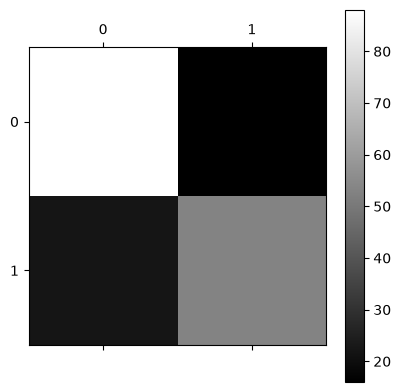

In [28]:
tree_clf = DecisionTreeClassifier(random_state=100)
tree_clf.fit(X_train, y_train)

tree_y_pred = tree_clf.predict(X_test)

# Accuracy
tree_acc = accuracy_score(tree_y_pred, y_test)
print(f"Accuracy: {tree_acc}")
print()

# Precision
tree_pre = precision_score(tree_y_pred, y_test)
print(f"Precision: {tree_pre}")
print()

# Recall
tree_rec = recall_score(tree_y_pred, y_test)
print(f"Recall: {tree_rec}")
print()

# F1 Score
tree_f1 = f1_score(tree_y_pred, y_test)
print(f"F1 Score: {tree_f1}")
print()

# Confusion Matrix
print("Confusion Matrix")
tree_conf_mx = confusion_matrix(tree_y_pred, y_test)
print(tree_conf_mx)
plt.matshow(tree_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()


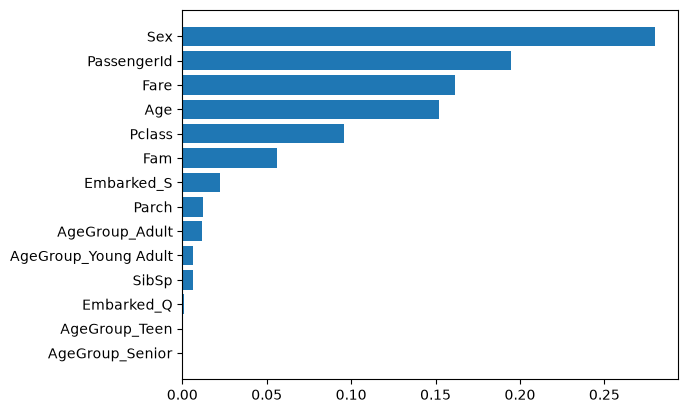

In [47]:
feature_importance = pd.Series(tree_clf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.barh(feature_importance.index, feature_importance.values)
plt.show()

### 3.2 Random Forest

Accuracy: 0.8659217877094972

Precision: 0.8405797101449275

Recall: 0.8169014084507042

F1 Score: 0.8285714285714286

Confusion Matrix
[[97 11]
 [13 58]]


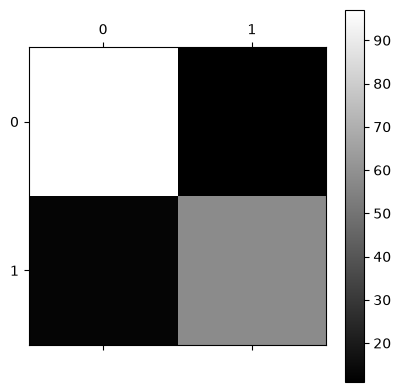

In [51]:
forest_clf = RandomForestClassifier(random_state=100)
forest_clf.fit(X_train, y_train)

forest_y_pred = forest_clf.predict(X_test)

# Accuracy
forest_acc = accuracy_score(forest_y_pred, y_test)
print(f"Accuracy: {forest_acc}")
print()

# Precision
forest_pre = precision_score(forest_y_pred, y_test)
print(f"Precision: {forest_pre}")
print()

# Recall
forest_rec = recall_score(forest_y_pred, y_test)
print(f"Recall: {forest_rec}")
print()

# F1 Score
forest_f1 = f1_score(forest_y_pred, y_test)
print(f"F1 Score: {forest_f1}")
print()

# Confusion Matrix
print("Confusion Matrix")
forest_conf_mx = confusion_matrix(forest_y_pred, y_test)
print(forest_conf_mx)
plt.matshow(forest_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()

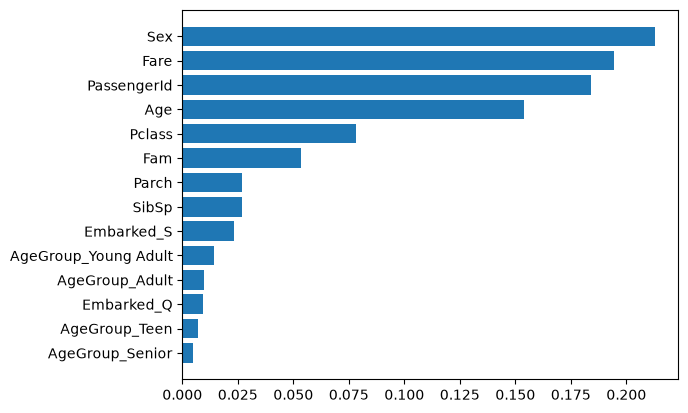

In [52]:
feature_importance = pd.Series(forest_clf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.barh(feature_importance.index, feature_importance.values)
plt.show()

### 3.3 K-Nearest Neighbors

Accuracy: 0.659217877094972

Precision: 0.2753623188405797

Recall: 0.6333333333333333

F1 Score: 0.3838383838383838

Confusion Matrix
[[99 50]
 [11 19]]


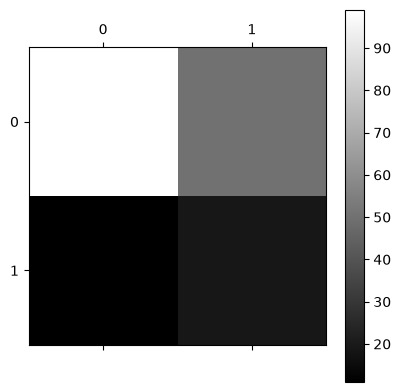

In [61]:
KNN_clf = KNeighborsClassifier(n_neighbors=12)
KNN_clf.fit(X_train, y_train)

KNN_y_pred = KNN_clf.predict(X_test)

# Accuracy
KNN_acc = accuracy_score(KNN_y_pred, y_test)
print(f"Accuracy: {KNN_acc}")
print()

# Precision
KNN_pre = precision_score(KNN_y_pred, y_test)
print(f"Precision: {KNN_pre}")
print()

# Recall
KNN_rec = recall_score(KNN_y_pred, y_test)
print(f"Recall: {KNN_rec}")
print()

# F1 Score
KNN_f1 = f1_score(KNN_y_pred, y_test)
print(f"F1 Score: {KNN_f1}")
print()

# Confusion Matrix
print("Confusion Matrix")
KNN_conf_mx = confusion_matrix(KNN_y_pred, y_test)
print(KNN_conf_mx)
plt.matshow(KNN_conf_mx, cmap=plt.cm.gray)
plt.colorbar()
plt.show()

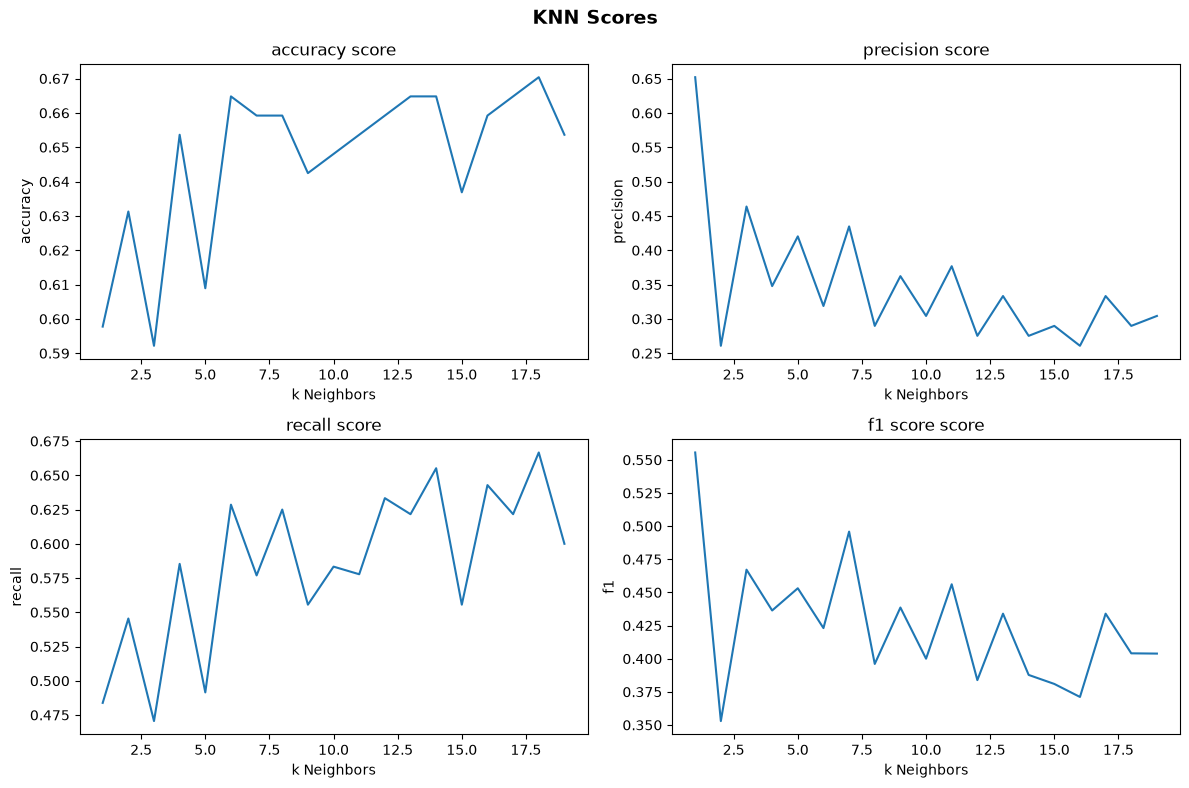

In [74]:
k_range = range(1,20)
k_acc = []
k_pre = []
k_rec = []
k_f1 = []

for k in k_range:
    KNN_clf = KNeighborsClassifier(n_neighbors=k)
    KNN_clf.fit(X_train, y_train)
    KNN_y_pred = KNN_clf.predict(X_test)
    k_acc.append(accuracy_score(KNN_y_pred, y_test))
    k_pre.append(precision_score(KNN_y_pred, y_test))
    k_rec.append(recall_score(KNN_y_pred, y_test))
    k_f1.append(f1_score(KNN_y_pred, y_test))


# Plot results

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    squeeze=False
)
axes = axes.flatten()

axes[0].plot(k_range, k_acc)
axes[0].set_xlabel("k Neighbors")
axes[0].set_ylabel("accuracy")
axes[0].set_title("accuracy score")

axes[1].plot(k_range, k_pre)
axes[1].set_xlabel("k Neighbors")
axes[1].set_ylabel("precision")
axes[1].set_title("precision score")

axes[2].plot(k_range, k_rec)
axes[2].set_xlabel("k Neighbors")
axes[2].set_ylabel("recall")
axes[2].set_title("recall score")

axes[3].plot(k_range, k_f1)
axes[3].set_xlabel("k Neighbors")
axes[3].set_ylabel("f1")
axes[3].set_title("f1 score score")

plt.suptitle("KNN Scores", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

From the above, it seems that k=7 nearest neighbors is optimal, though very noisy, so shouldn't necessarily hold to this, especially with cross-evaluation which may smooth these scores.

### 3.4 Support Vector Machine